<a href="https://colab.research.google.com/github/jabondias/Applied-Plotting-Charting-and-Data-Representation-in-Python/blob/master/Stock_Market_Analysis_and_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stock Market Analysis and Prediction

## Importing packages and datasets

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

# For reading stock data from yahoo
from pandas_datareader.data import DataReader

# For time stamps
from datetime import datetime

## Importing datasets from Yahoo reader

In [3]:
import yfinance as yf

# The tech stocks we'll use for this analysis
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']

# Set up End and Start times for data grab
end = datetime.now()
start = datetime(end.year - 1, end.month, end.day)


#For loop for grabing yahoo finance data and setting as a dataframe
for stock in tech_list:
    # Set DataFrame as the Stock Ticker
    globals()[stock] = yf.download(stock, start=start, end=end)

/tmp/ipykernel_10315/4125285449.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_10315/4125285449.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_10315/4125285449.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_10315/4125285449.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


## Display data characteristics

In [4]:
company_list = [AAPL, GOOG, MSFT, AMZN]
company_name = ["APPLE", "GOOGLE", "MICROSOFT", "AMAZON"]

for company, com_name in zip(company_list, company_name):
    company["company_name"] = com_name

df = pd.concat(company_list, axis=0)
df.tail(10)

Price,Close,High,Low,Open,Volume,company_name,Close,High,Low,Open,...,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,GOOG,GOOG,GOOG,GOOG,...,MSFT,MSFT,MSFT,MSFT,MSFT,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-09,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,213.490005,213.820007,207.110001,210.449997,54642900.0
2026-03-10,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,214.330002,215.649994,212.429993,214.190002,35678800.0
2026-03-11,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,212.649994,217.000000,211.350006,215.710007,34199300.0
2026-03-12,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,209.529999,211.710007,208.149994,210.389999,44349500.0
2026-03-13,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,207.669998,210.559998,206.220001,209.610001,35662100.0
2026-03-16,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,211.740005,212.720001,207.449997,208.350006,42209300.0
2026-03-17,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,215.199997,215.699997,212.429993,212.820007,44969900.0
2026-03-18,NaN,NaN,NaN,NaN,NaN,AMAZON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,209.869995,215.139999,208.830002,213.929993,37846600.0


## Individual Stocks Description

In [5]:
AAPL.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,237.970775,240.497821,235.420395,237.843148,5.303114e+07
std,29.167263,29.062087,29.312969,29.312312,2.344722e+07
min,171.671799,189.514035,168.475737,171.203815,1.791060e+07
25%,209.417721,211.360860,207.183811,209.335460,3.957675e+07
50%,244.918182,247.104016,241.472736,243.450975,4.674245e+07
75%,264.307503,267.179901,261.397977,263.572502,5.582172e+07
max,285.922455,288.350192,283.035157,285.932471,1.843959e+08


In [6]:
GOOG.describe()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,240.384774,243.168625,237.204469,240.128151,2.407057e+07
std,63.714572,64.390813,62.899942,63.761844,1.031125e+07
min,146.075012,150.539567,142.168513,142.895994,6.138200e+06
25%,176.637150,177.868872,173.713727,175.822740,1.785890e+07
50%,244.717819,246.798993,240.637351,243.619310,2.161280e+07
75%,306.261070,308.926114,302.179631,305.505934,2.612160e+07
max,344.657196,349.903504,338.351644,348.269676,7.872980e+07


In [7]:
MSFT.describe()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,465.654062,469.710646,461.472825,465.821115,2.498539e+07
std,48.747489,48.440973,49.373190,49.225104,1.254994e+07
min,351.866272,361.710926,342.170496,348.214224,5.855900e+06
25%,429.487068,434.501109,422.623588,429.002330,1.678188e+07
50%,480.139099,483.351774,475.015798,479.794469,2.152995e+07
75%,506.224953,509.404217,502.388570,506.307097,2.853578e+07
max,539.825256,552.242002,538.530652,552.023241,1.288553e+08


In [8]:
AMZN.describe()

Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,218.311680,220.805280,215.664544,218.335160,4.698813e+07
std,17.298008,17.116356,17.843546,17.803222,2.187200e+07
min,167.320007,169.600006,161.380005,162.000000,1.142050e+07
25%,208.579998,210.682499,205.237499,208.162506,3.471050e+07
50%,221.625000,223.580002,219.209999,221.895004,4.140615e+07
75%,230.697506,232.472496,228.527504,230.732506,5.149288e+07
max,254.000000,258.600006,252.899994,255.360001,1.792109e+08


## Visualization of stocks

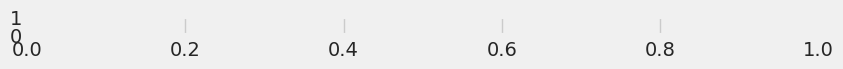

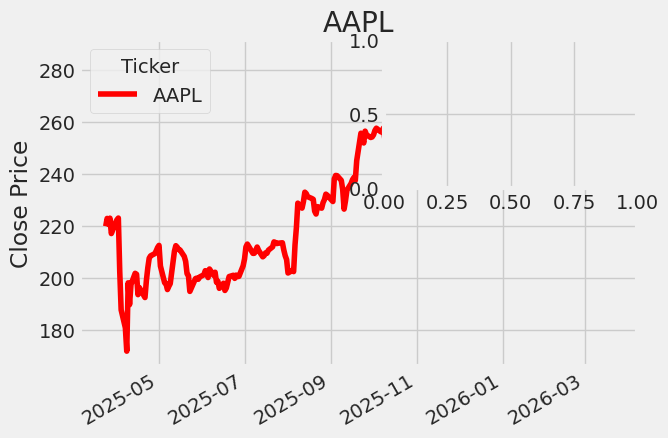

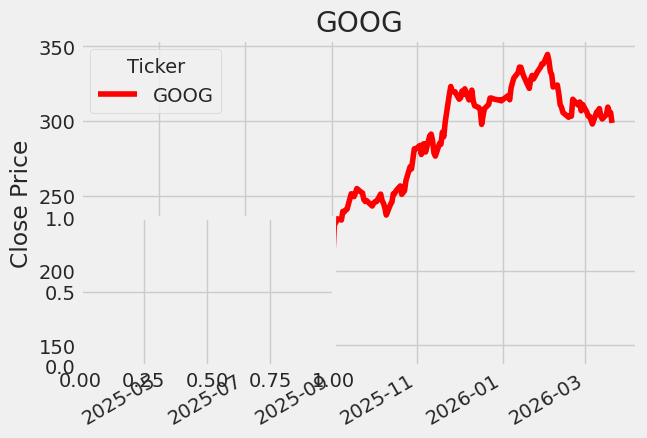

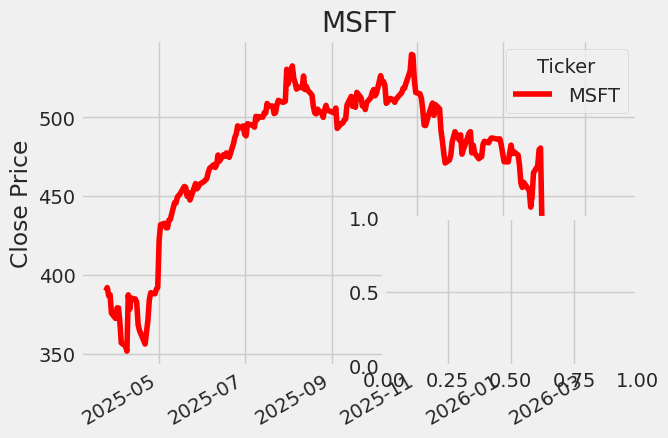

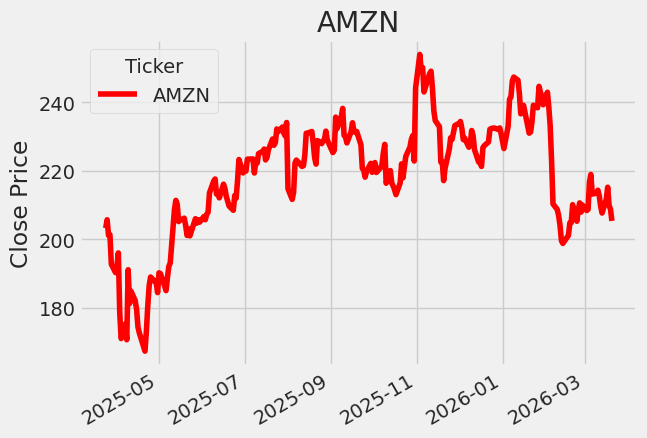

In [12]:
plt.figure(figsize=(20, 8))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Close'].plot(color='r')
    plt.ylabel('Close Price')
    plt.xlabel(None)
    plt.title(f'{tech_list[i - 1]}')

## Daily stocks exchange

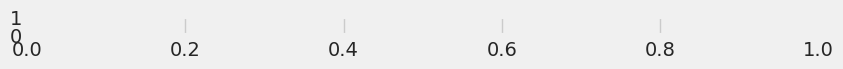

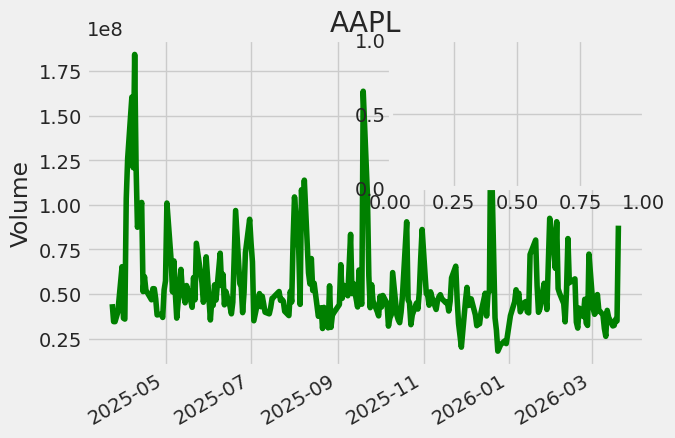

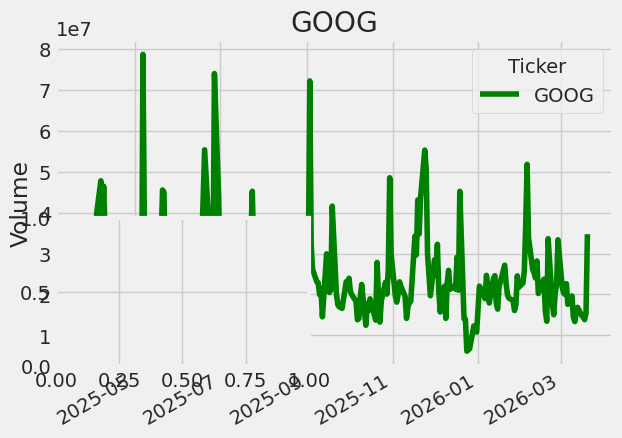

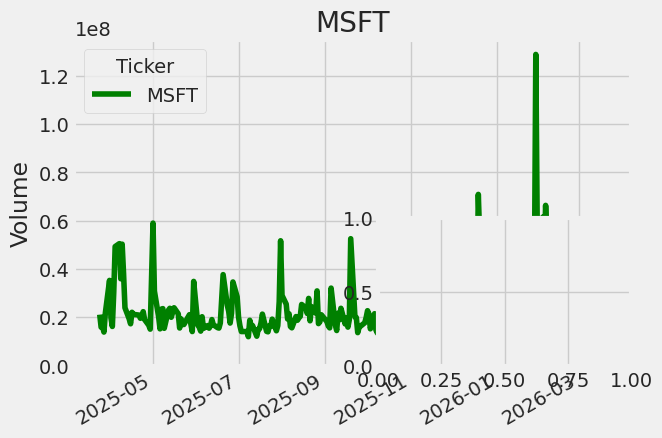

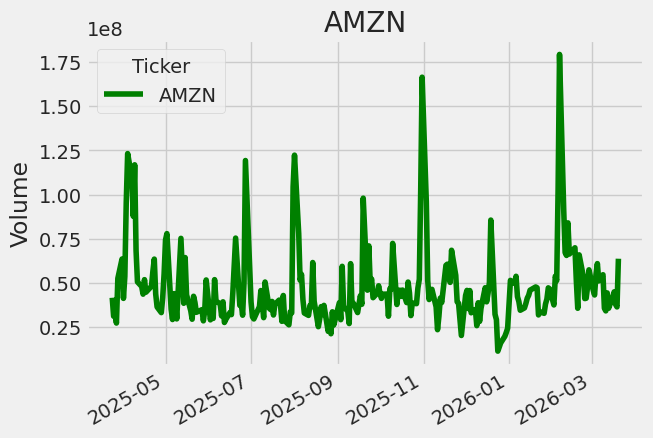

In [13]:
# Now let's plot the total volume of stock being traded each day
plt.figure(figsize=(20, 8))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Volume'].plot(color='g')
    plt.ylabel('Volume')
    plt.xlabel(None)
    plt.title(f"{tech_list[i - 1]}")

## Moving Average of various stocks

In [15]:
ma_day = [10, 20, 50]

for ma in ma_day:
    for company in company_list:
        column_name = f"MA for {ma} days"
        company[column_name] = company['Close'].rolling(ma).mean()

/tmp/ipykernel_10315/2281455095.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df.groupby("company_name").hist(figsize=(20, 10));


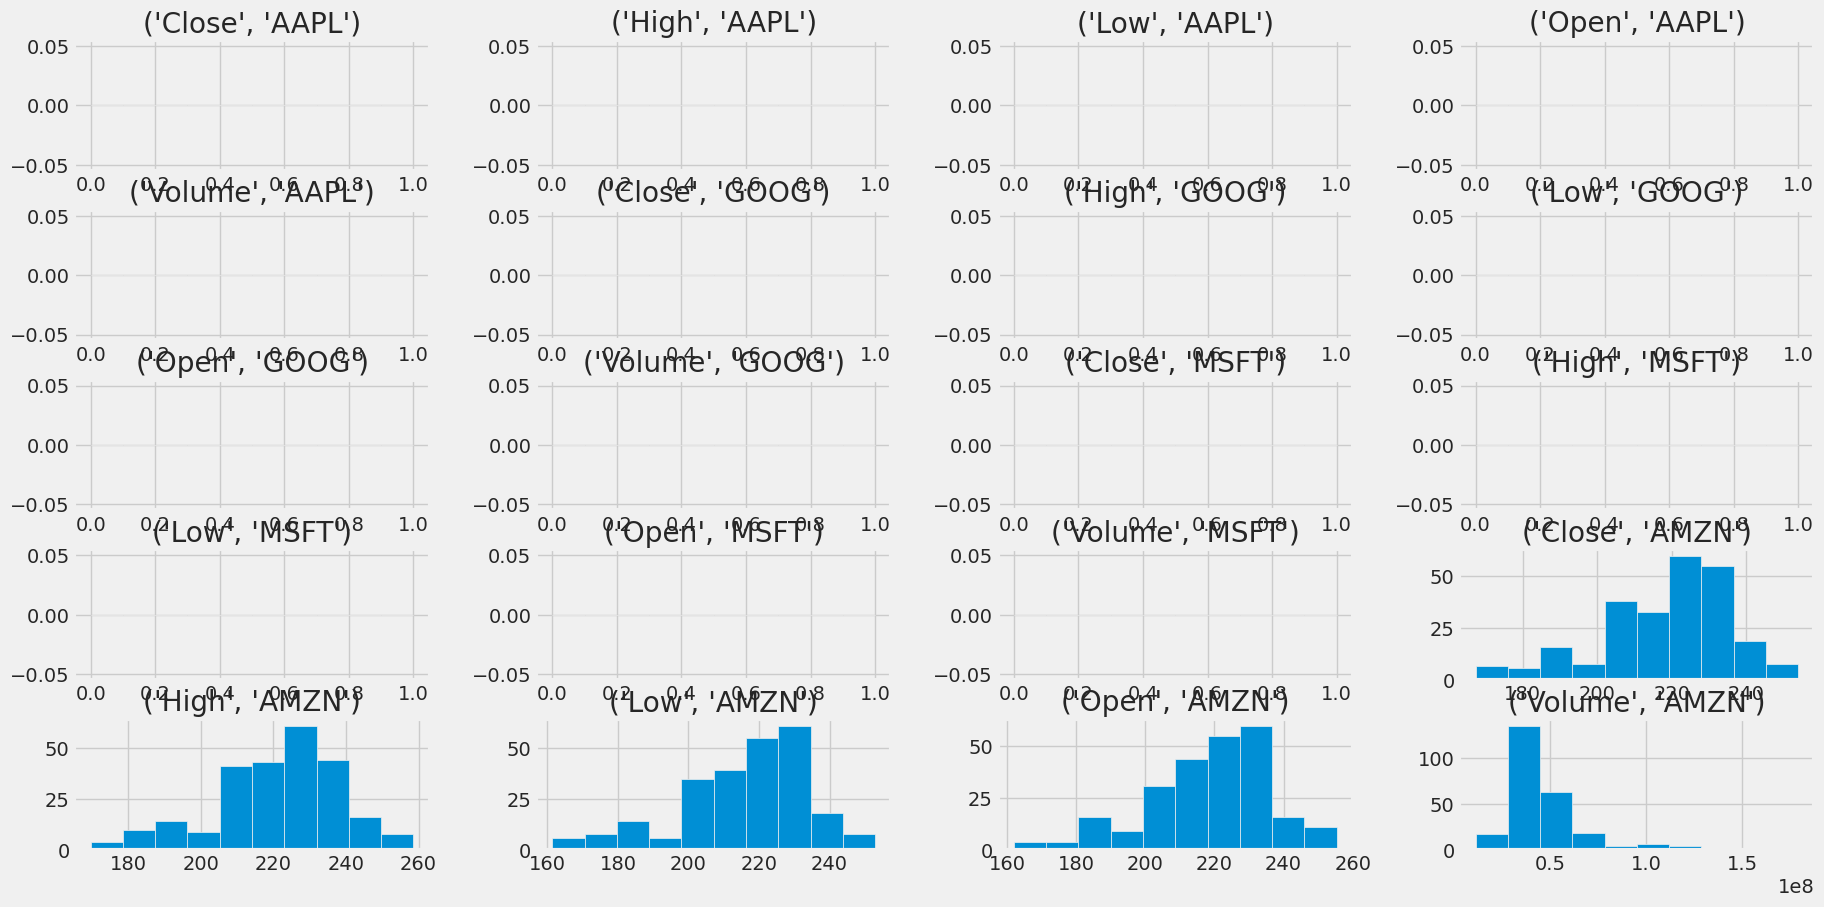

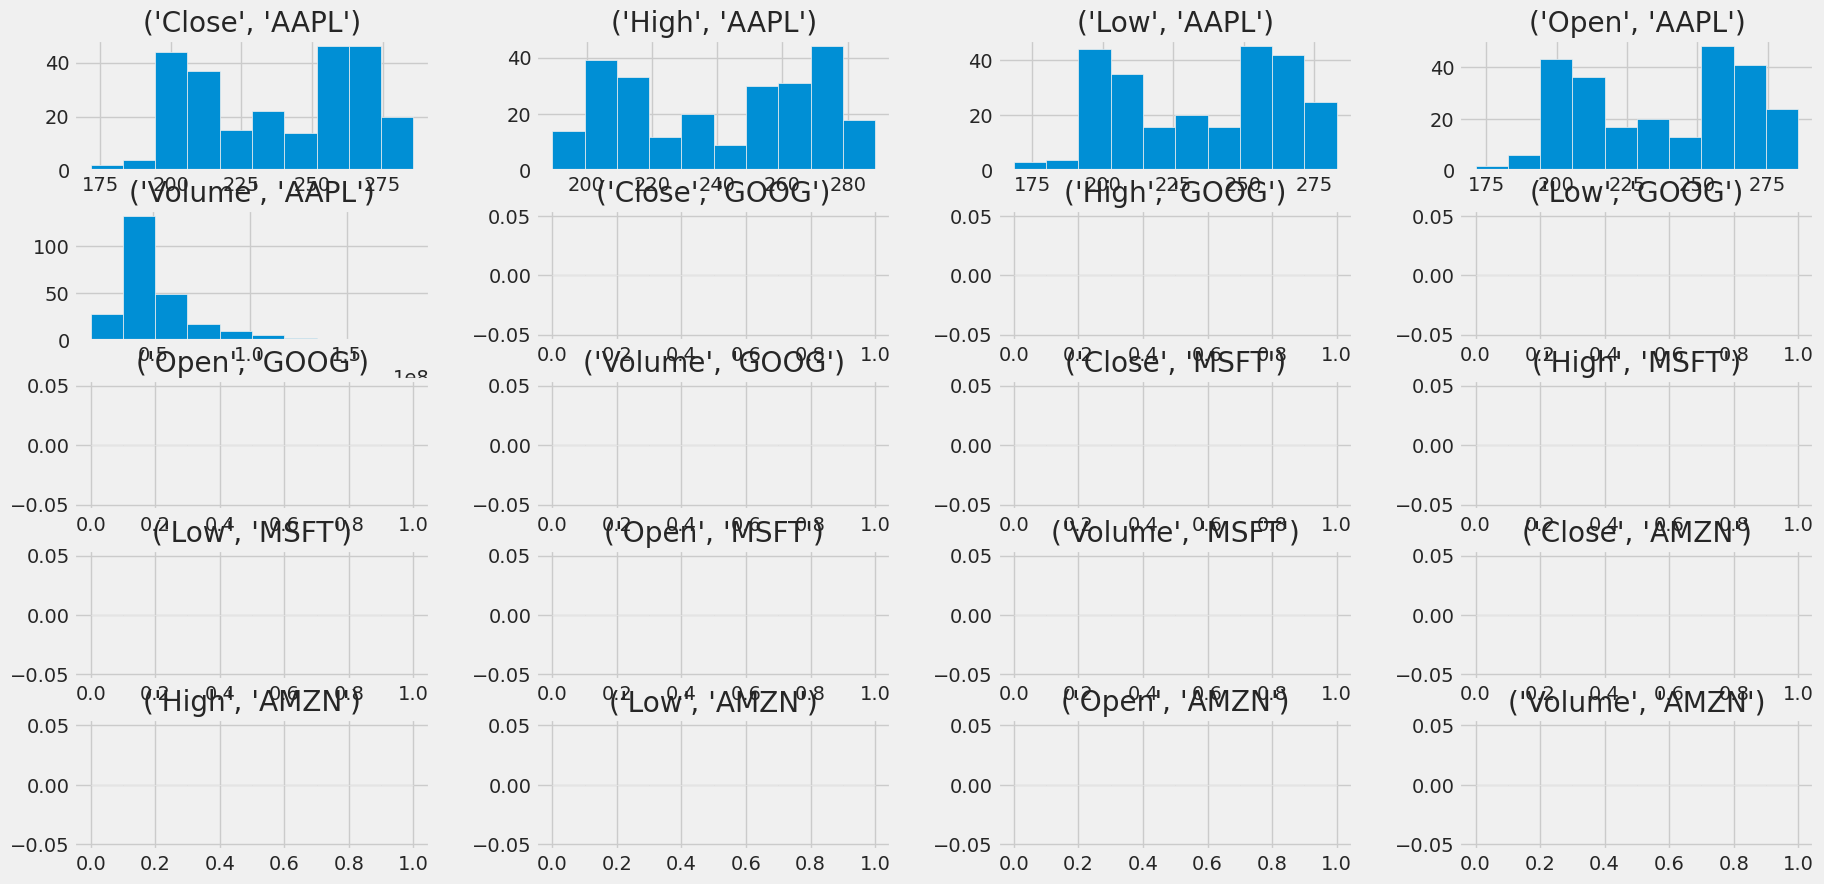

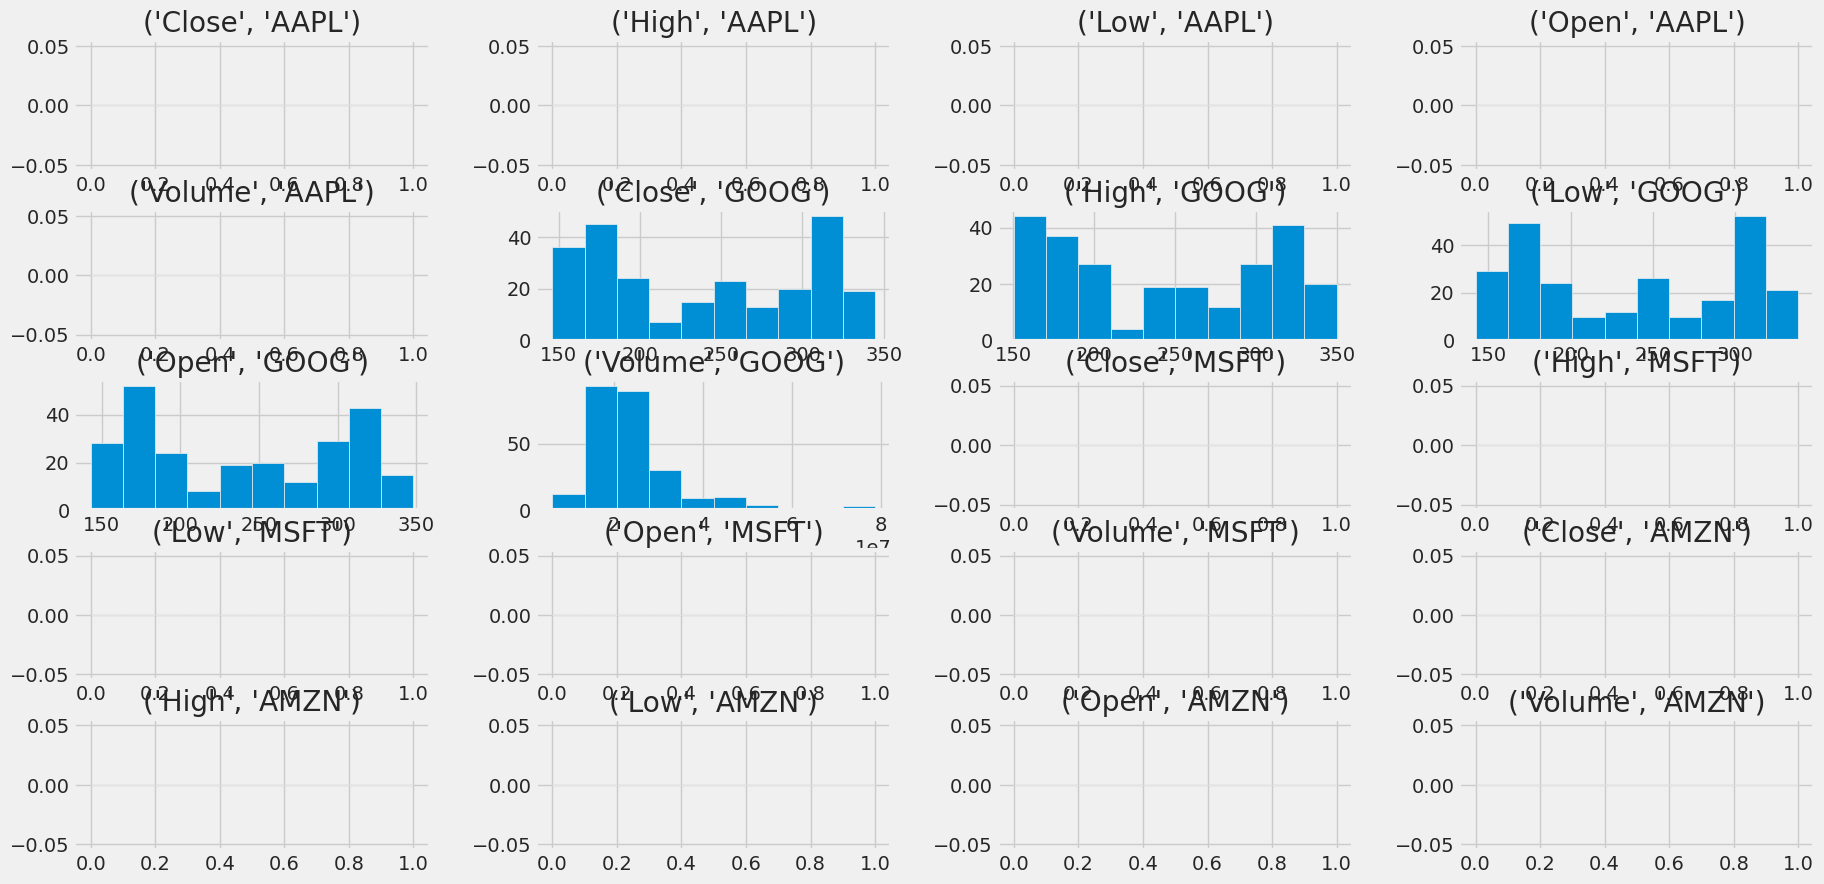

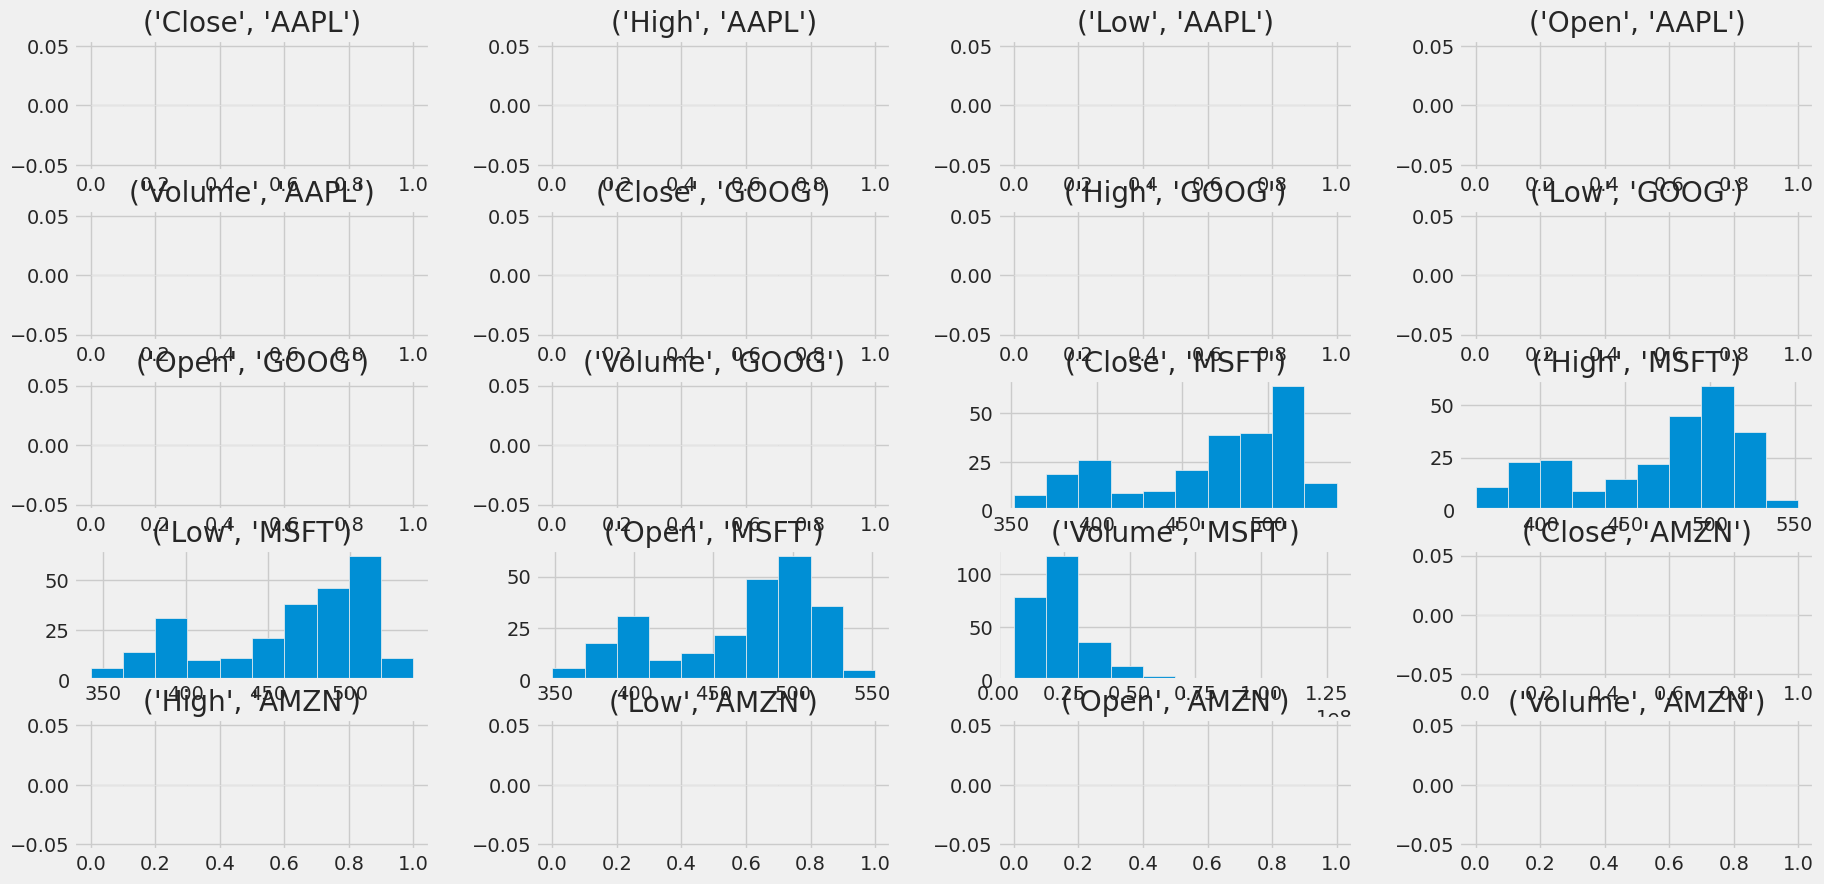

In [16]:
df.groupby("company_name").hist(figsize=(20, 10));

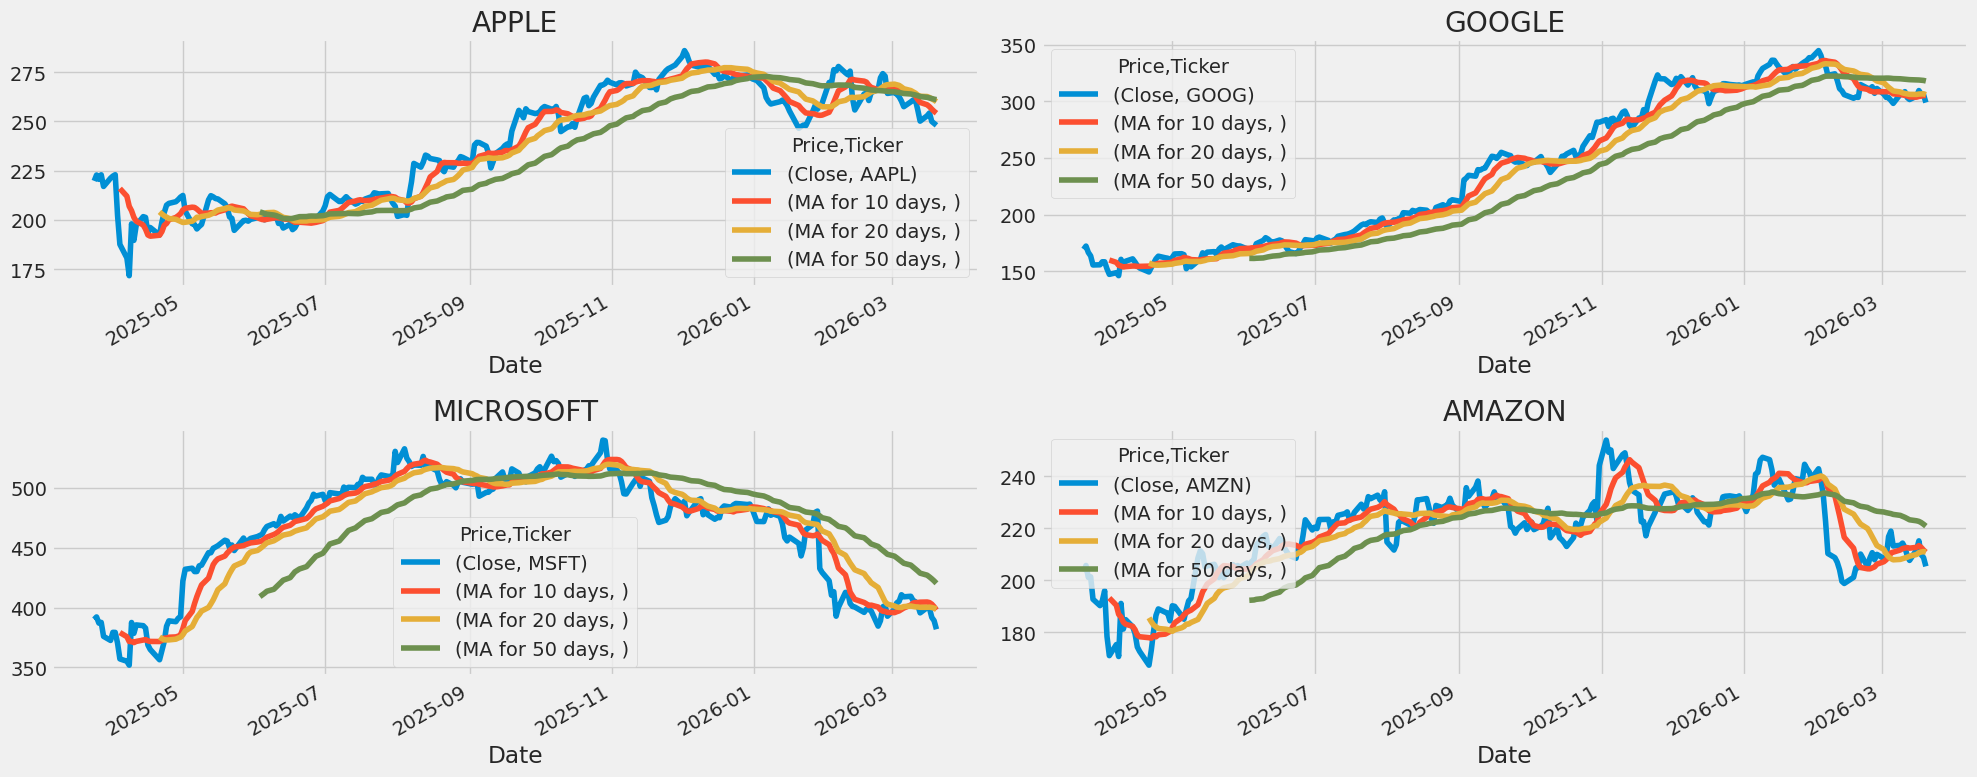

In [18]:
fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(8)
fig.set_figwidth(20)

AAPL[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,0])
axes[0,0].set_title('APPLE')

GOOG[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,1])
axes[0,1].set_title('GOOGLE')

MSFT[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,0])
axes[1,0].set_title('MICROSOFT')

AMZN[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,1])
axes[1,1].set_title('AMAZON')

fig.tight_layout()

## Daily average return of stocks

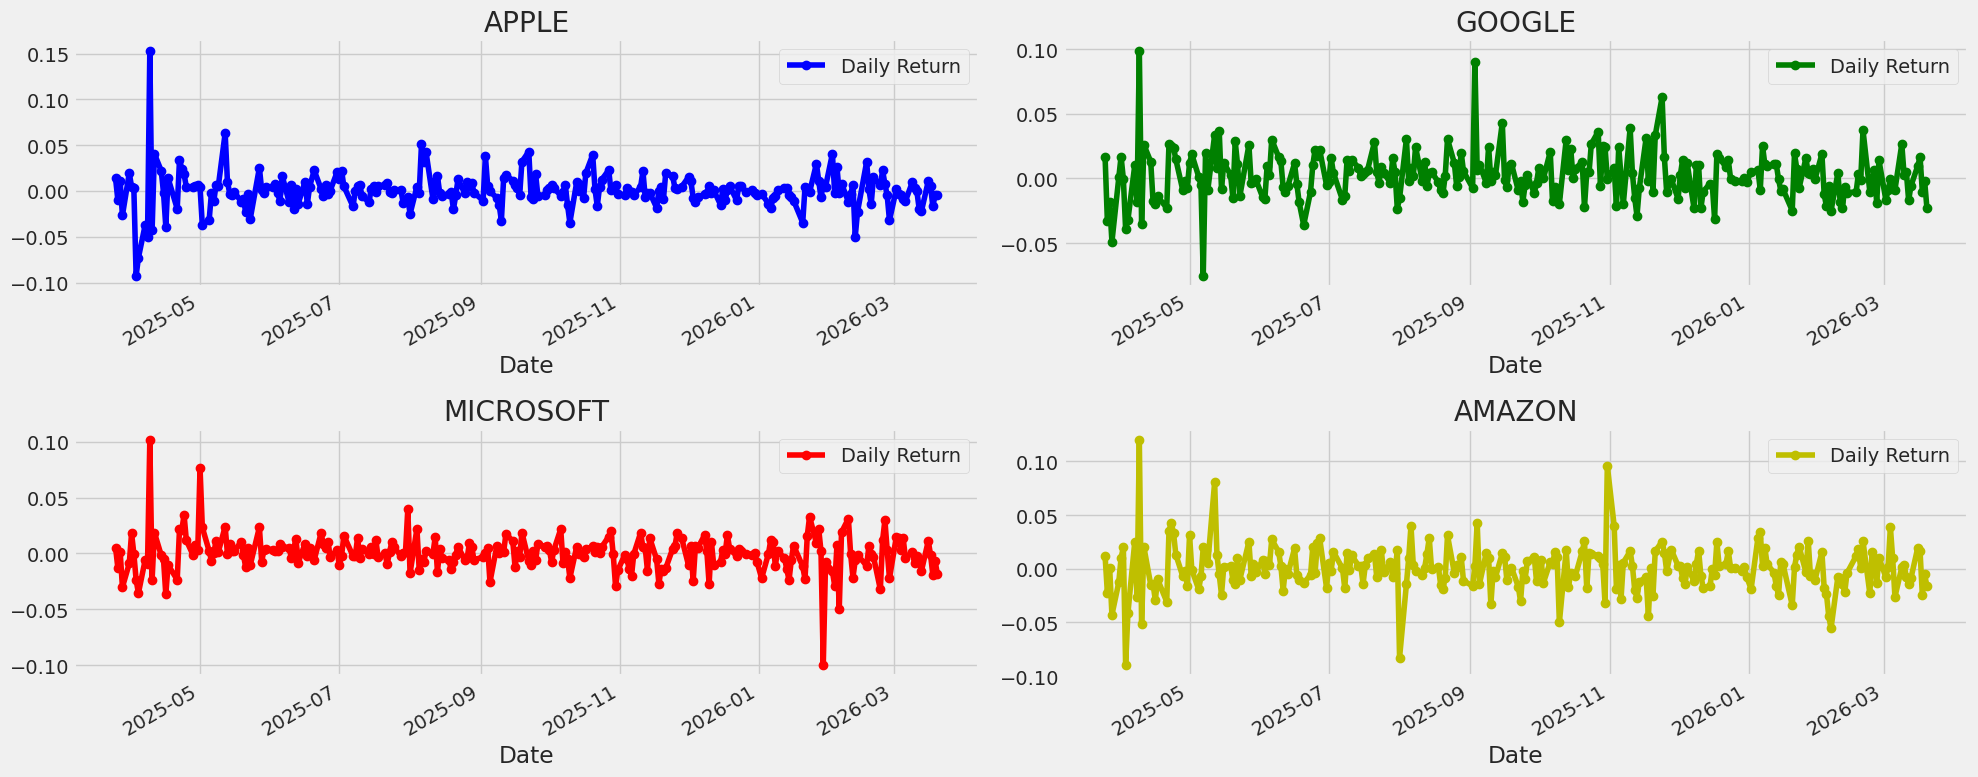

In [20]:
# We'll use pct_change to find the percent change for each day
for company in company_list:
    company['Daily Return'] = company['Close'].pct_change()

# Then we'll plot the daily return percentage
fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(8)
fig.set_figwidth(20)

AAPL['Daily Return'].plot(ax=axes[0,0], legend=True,  marker='o',color='b')
axes[0,0].set_title('APPLE')

GOOG['Daily Return'].plot(ax=axes[0,1], legend=True,  marker='o',color='g')
axes[0,1].set_title('GOOGLE')

MSFT['Daily Return'].plot(ax=axes[1,0], legend=True, marker='o',color='r')
axes[1,0].set_title('MICROSOFT')

AMZN['Daily Return'].plot(ax=axes[1,1], legend=True,  marker='o',color='y')
axes[1,1].set_title('AMAZON')

fig.tight_layout()

/tmp/ipykernel_10315/1187399222.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(company['Daily Return'].dropna(), bins=100, color='purple')
/tmp/ipykernel_10315/1187399222.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(company['Daily Return'].dropna(), bins=100, color='purple')
/tmp/ipy

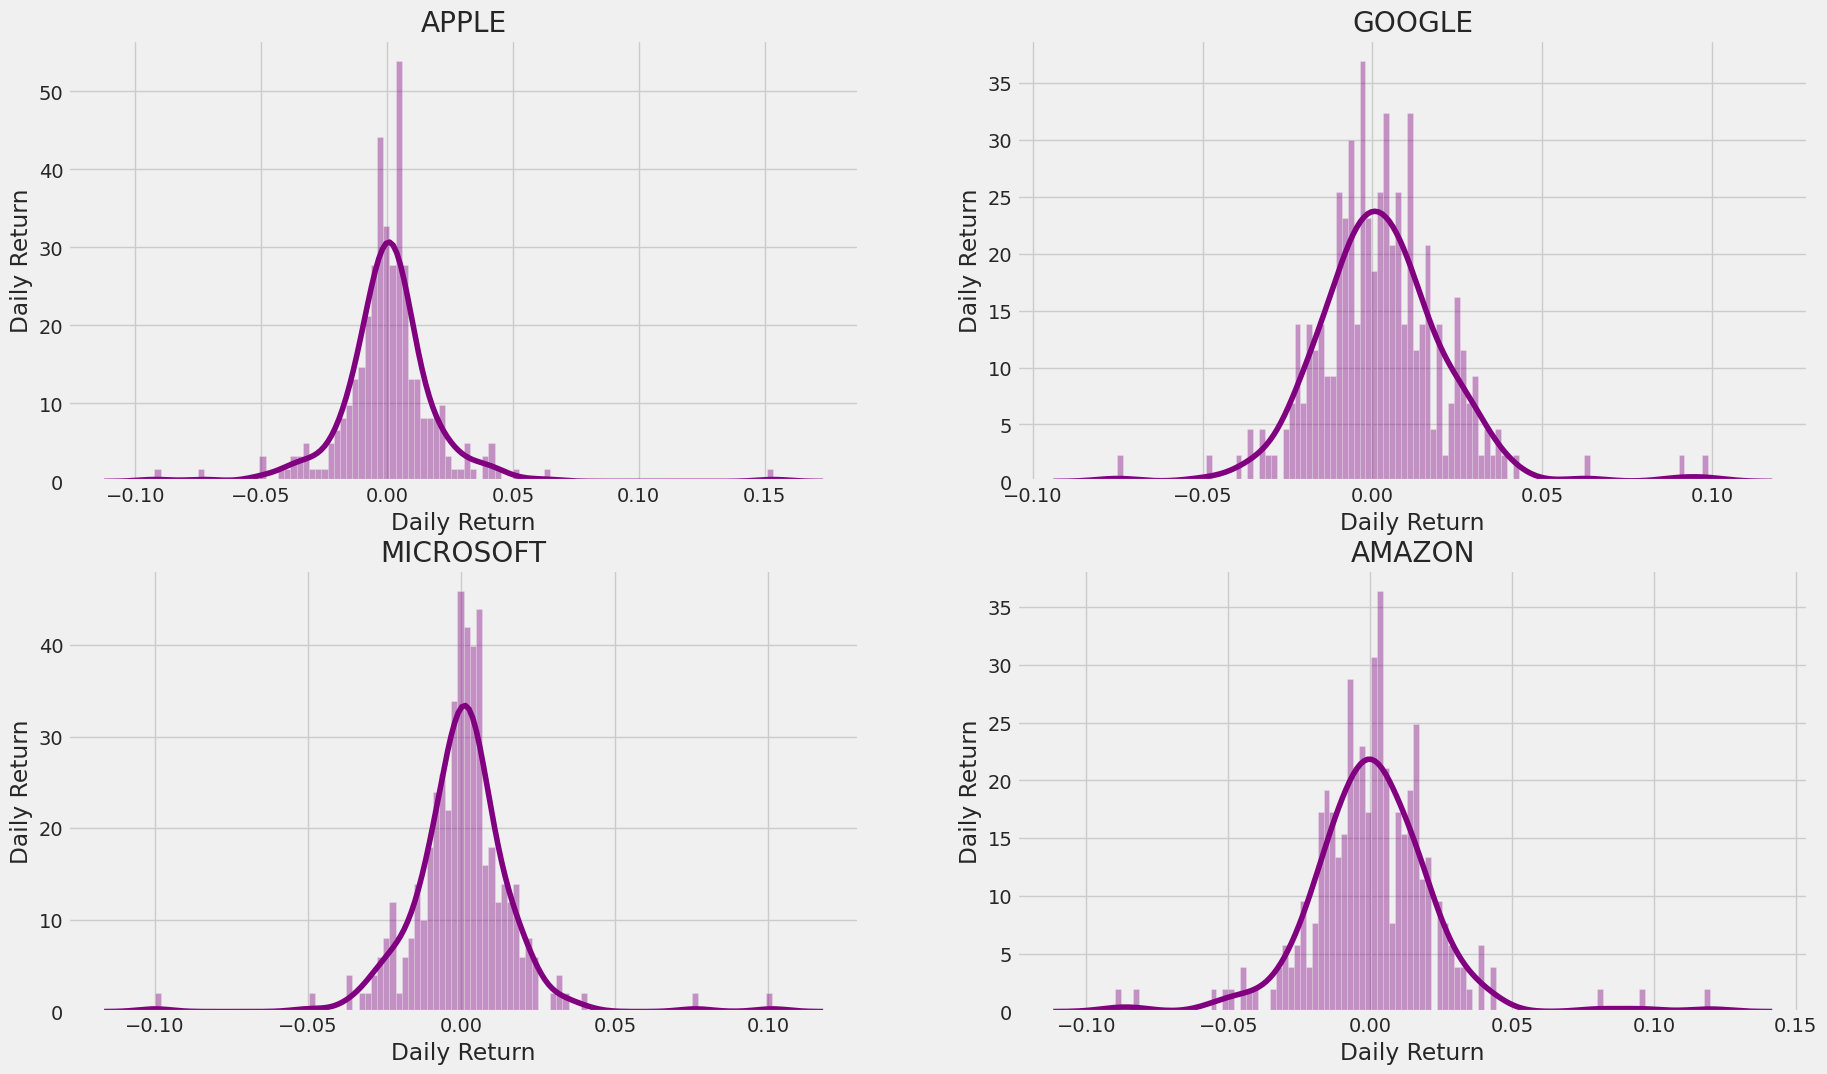

In [21]:
plt.figure(figsize=(20, 12))

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    sns.distplot(company['Daily Return'].dropna(), bins=100, color='purple')
    plt.ylabel('Daily Return')
    plt.title(f'{company_name[i - 1]}')

## Correlation between stocks

In [23]:
closing_df = pd.concat([company['Close'] for company in company_list], axis=1)
closing_df.columns = tech_list
closing_df.head()

,AAPL,GOOG,MSFT,AMZN
Date,,,,
2025-03-24,219.772156,169.344559,390.093597,203.259995
2025-03-25,222.779037,172.194687,392.157806,205.710007
2025-03-26,220.568680,166.564178,387.007233,201.130005
2025-03-27,222.878616,163.514709,387.612579,201.360001
2025-03-28,216.954422,155.522339,375.922089,192.720001


In [24]:
tech_rets = closing_df.pct_change()
tech_rets.head()

,AAPL,GOOG,MSFT,AMZN
Date,,,,
2025-03-24,NaN,NaN,NaN,NaN
2025-03-25,0.013682,0.016830,0.005292,0.012054
2025-03-26,-0.009922,-0.032699,-0.013134,-0.022264
2025-03-27,0.010473,-0.018308,0.001564,0.001144
2025-03-28,-0.026580,-0.048879,-0.030160,-0.042908


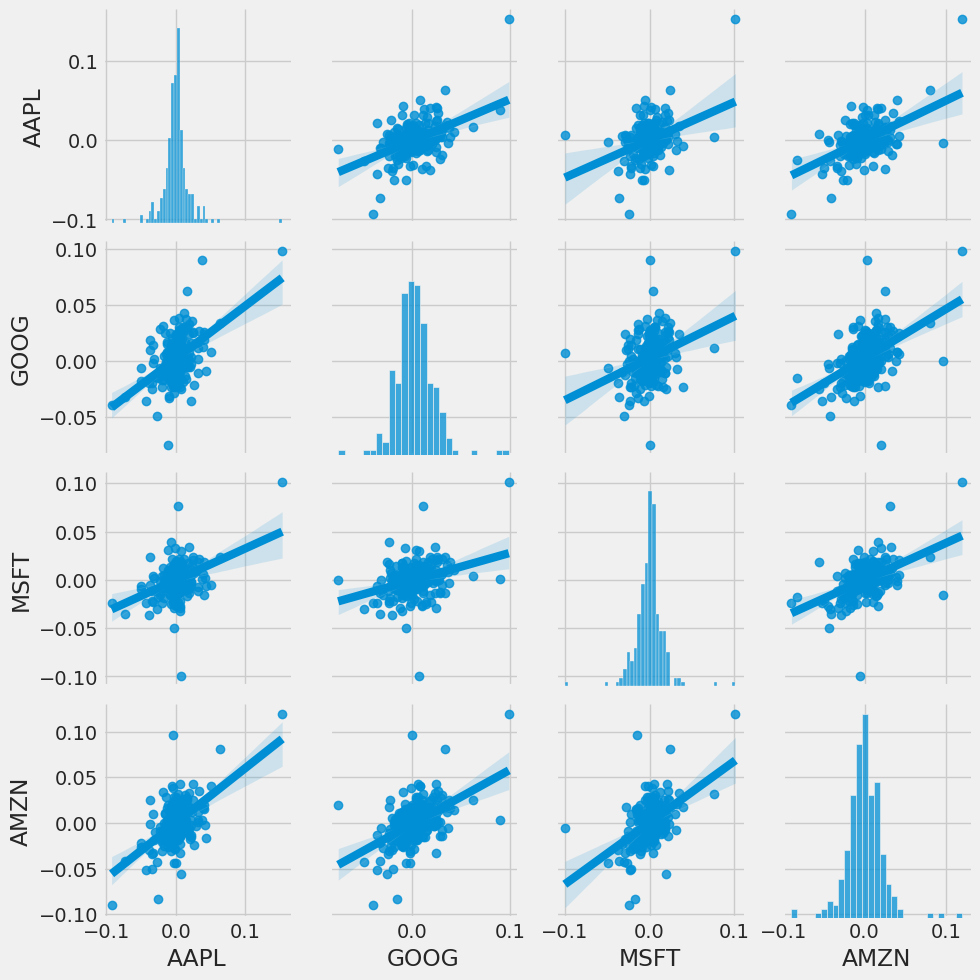

In [25]:
sns.pairplot(tech_rets, kind='reg')

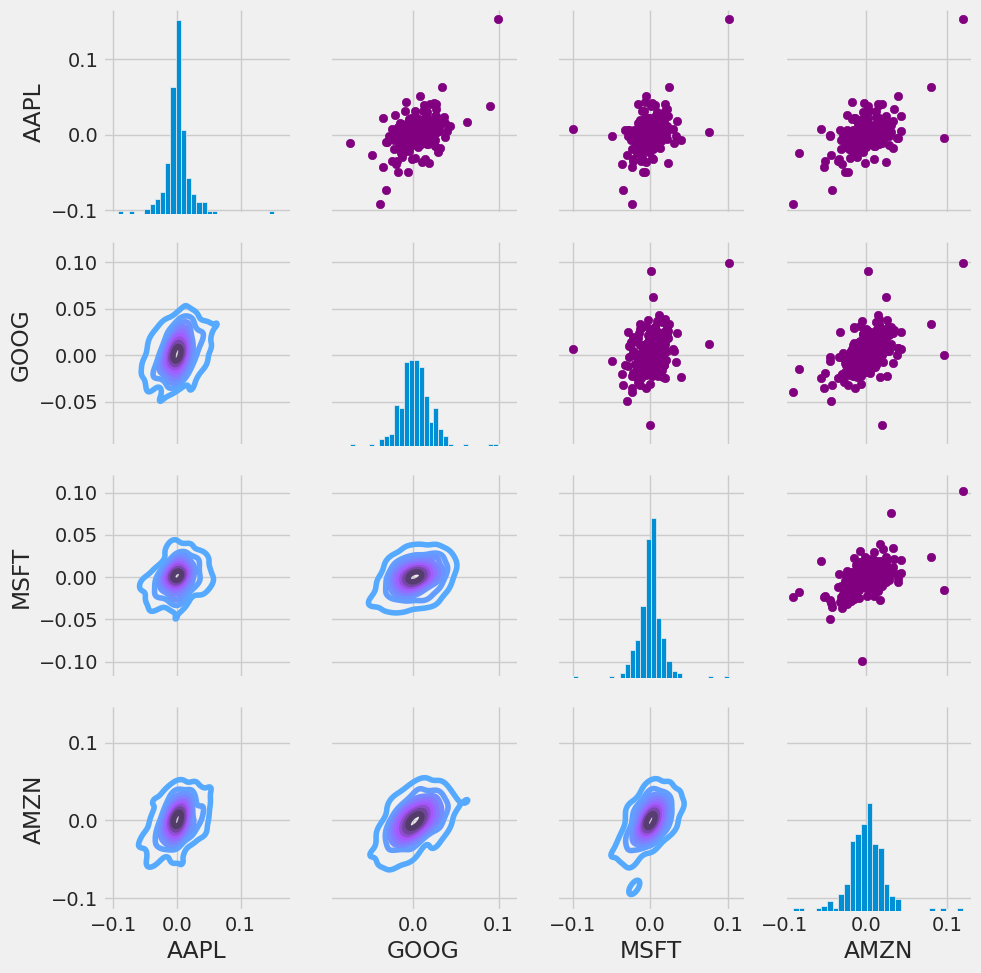

In [26]:
# Set up our figure by naming it returns_fig, call PairPLot on the DataFrame
return_fig = sns.PairGrid(tech_rets.dropna())

# Using map_upper we can specify what the upper triangle will look like.
return_fig.map_upper(plt.scatter, color='purple')

# We can also define the lower triangle in the figure, inclufing the plot type (kde)
# or the color map (BluePurple)
return_fig.map_lower(sns.kdeplot, cmap='cool_d')

# Finally we'll define the diagonal as a series of histogram plots of the daily return
return_fig.map_diag(plt.hist, bins=30)

<Axes: >

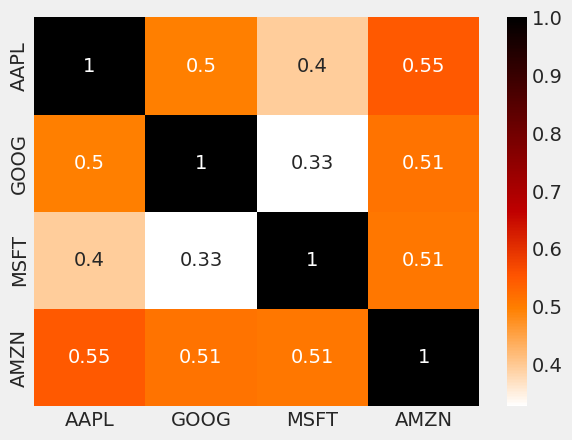

In [27]:
sns.heatmap(tech_rets.corr(), annot=True, cmap='gist_heat_r')

<Axes: >

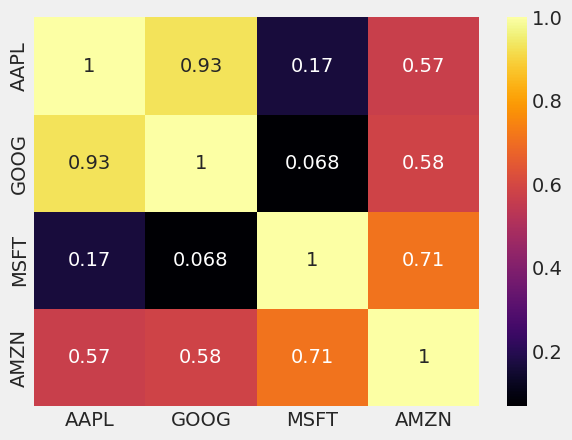

In [28]:
sns.heatmap(closing_df.corr(), annot=True, cmap='inferno')

## Risk on a particular stock

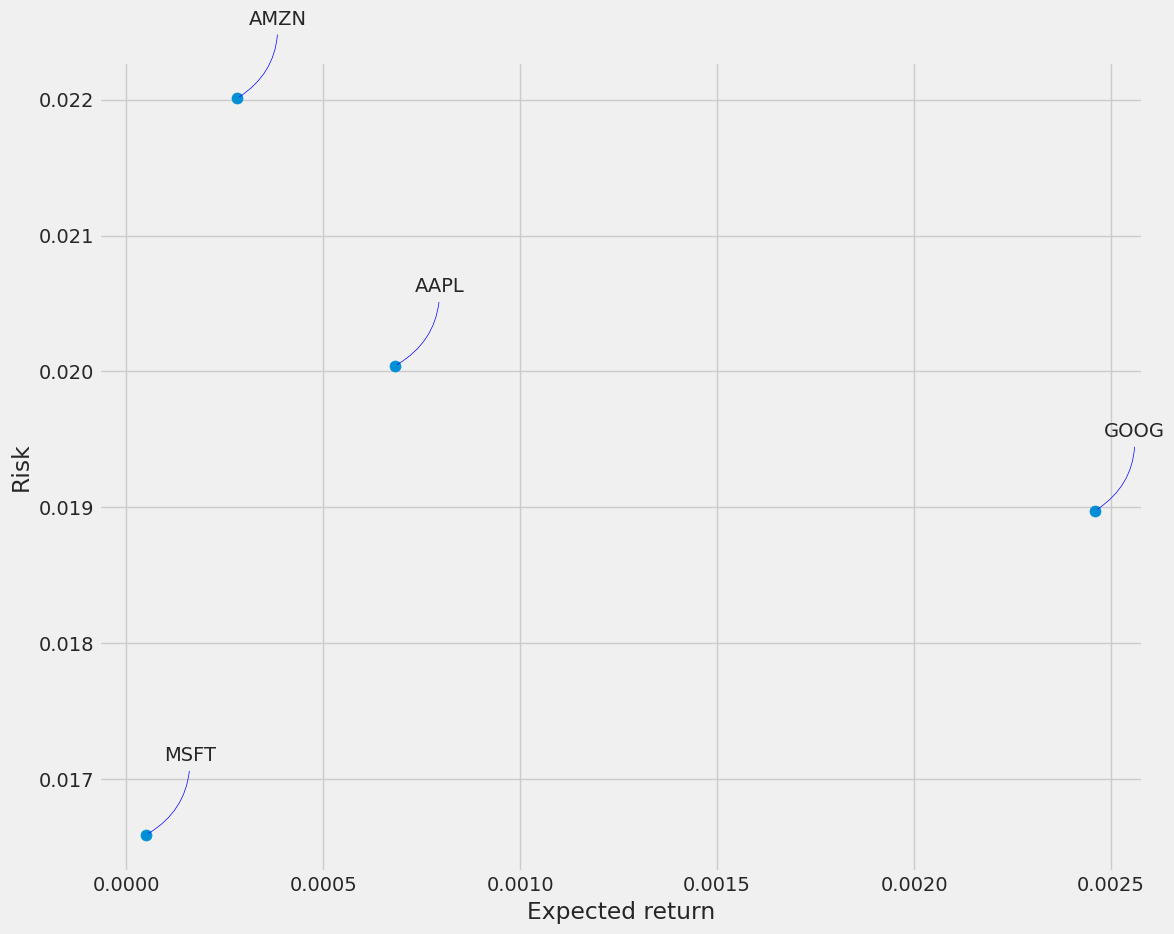

In [29]:
rets = tech_rets.dropna()

area = np.pi*20

plt.figure(figsize=(12, 10))
plt.scatter(rets.mean(), rets.std(), s=area)
plt.xlabel('Expected return')
plt.ylabel('Risk')

for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(label, xy=(x, y), xytext=(50, 50), textcoords='offset points', ha='right', va='bottom',
                 arrowprops=dict(arrowstyle='-', color='blue', connectionstyle='arc3,rad=-0.3'))

In [31]:
#Get the stock quote
df = AAPL
#Show teh data
df

Price,Close,High,Low,Open,Volume,company_name,MA for 10 days,MA for 20 days,MA for 50 days,Daily Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Date,,,,,,,,,,
2025-03-24,219.772156,220.518901,217.631492,220.040988,44299500,APPLE,NaN,NaN,NaN,NaN
2025-03-25,222.779037,223.127525,219.124965,219.811973,34493600,APPLE,NaN,NaN,NaN,0.013682
2025-03-26,220.568680,224.043541,219.513282,222.540083,34466100,APPLE,NaN,NaN,NaN,-0.009922
2025-03-27,222.878616,224.013669,219.602885,220.429285,37094800,APPLE,NaN,NaN,NaN,0.010473
2025-03-28,216.954422,222.838779,216.735375,220.708066,39818600,APPLE,NaN,NaN,NaN,-0.026580
...,...,...,...,...,...,...,...,...,...,...
2026-03-16,252.820007,253.889999,249.880005,252.110001,32074200,APPLE,258.423997,262.601499,262.204839,0.010795
2026-03-17,254.229996,255.130005,252.179993,252.960007,32361600,APPLE,257.471997,262.118999,261.874306,0.005577


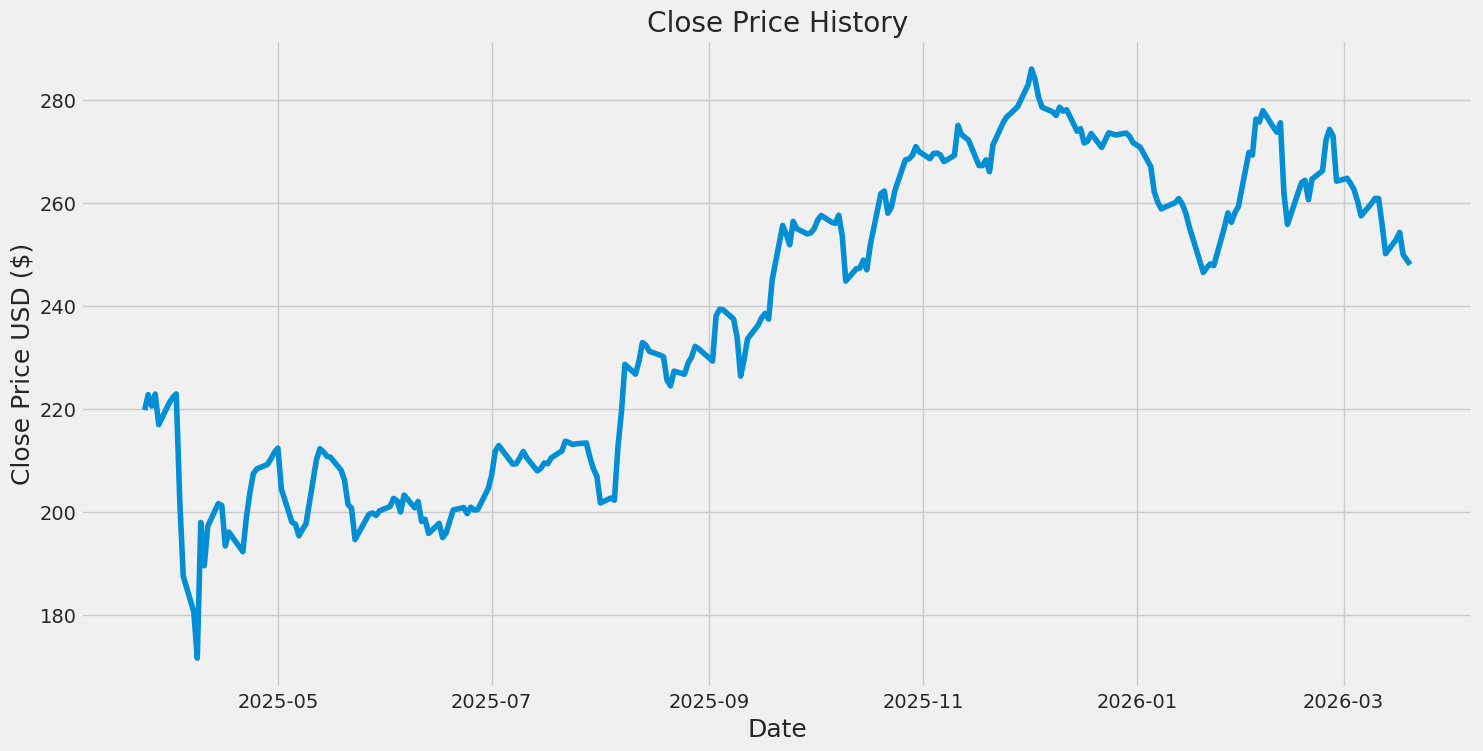

In [32]:
plt.figure(figsize=(16,8))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [36]:
#Create a new dataframe with only the 'Close column
data = df[[('Close', 'AAPL')]]
#Convert the dataframe to a numpy array
dataset = data.values
#Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * .8 ))

training_data_len

200

In [37]:
#Scale the data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.42100727],
       [0.44732556],
       [0.427979  ],
       [0.44819714],
       [0.39634454],
       [0.43320769],
       [0.44244531],
       [0.44854559],
       [0.26815128],
       [0.13908657],
       [0.07878084],
       [0.        ],
       [0.23032946],
       [0.15686439],
       [0.22422919],
       [0.26231237],
       [0.25900086],
       [0.19041604],
       [0.2140329 ],
       [0.18074276],
       [0.23808556],
       [0.28043904],
       [0.31329326],
       [0.32122378],
       [0.32871851],
       [0.33804334],
       [0.3492851 ],
       [0.35643138],
       [0.28697511],
       [0.23067804],
       [0.2273664 ],
       [0.20767126],
       [0.21847749],
       [0.22754083],
       [0.33679179],
       [0.35546577],
       [0.35023014],
       [0.34255124],
       [0.34089328],
       [0.31925237],
       [0.30249825],
       [0.26087465],
       [0.25450459],
       [0.20136224],
       [0.24446951],
       [0.24630202],
       [0.24220053],
       [0.250

In [38]:
#Create the training data set
#Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
#Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()

# Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

#Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_train.shape

[array([0.42100727, 0.44732556, 0.427979  , 0.44819714, 0.39634454,
       0.43320769, 0.44244531, 0.44854559, 0.26815128, 0.13908657,
       0.07878084, 0.        , 0.23032946, 0.15686439, 0.22422919,
       0.26231237, 0.25900086, 0.19041604, 0.2140329 , 0.18074276,
       0.23808556, 0.28043904, 0.31329326, 0.32122378, 0.32871851,
       0.33804334, 0.3492851 , 0.35643138, 0.28697511, 0.23067804,
       0.2273664 , 0.20767126, 0.21847749, 0.22754083, 0.33679179,
       0.35546577, 0.35023014, 0.34255124, 0.34089328, 0.31925237,
       0.30249825, 0.26087465, 0.25450459, 0.20136224, 0.24446951,
       0.24630202, 0.24220053, 0.25005426, 0.25747139, 0.2711715 ,
       0.2672447 , 0.2481344 , 0.27684333, 0.25528976, 0.26593573,
       0.23199103, 0.23565605, 0.21165922, 0.22884967, 0.20459107])]
[np.float64(0.21279350963622057)]

[array([0.42100727, 0.44732556, 0.427979  , 0.44819714, 0.39634454,
       0.43320769, 0.44244531, 0.44854559, 0.26815128, 0.13908657,
       0.07878084, 0.  

## Stock portfolio prediction using LSTM

In [39]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

#Build the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(50, return_sequences= False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

#Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0199


In [40]:
#Create the testing data set
#Create a new array containing scaled values from index 1543 to 2002
test_data = scaled_data[training_data_len - 60: , :]
#Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 306ms/step


np.float64(10.199956547132556)

## Visualizing Stock Predictions

/tmp/ipykernel_10315/3436872259.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


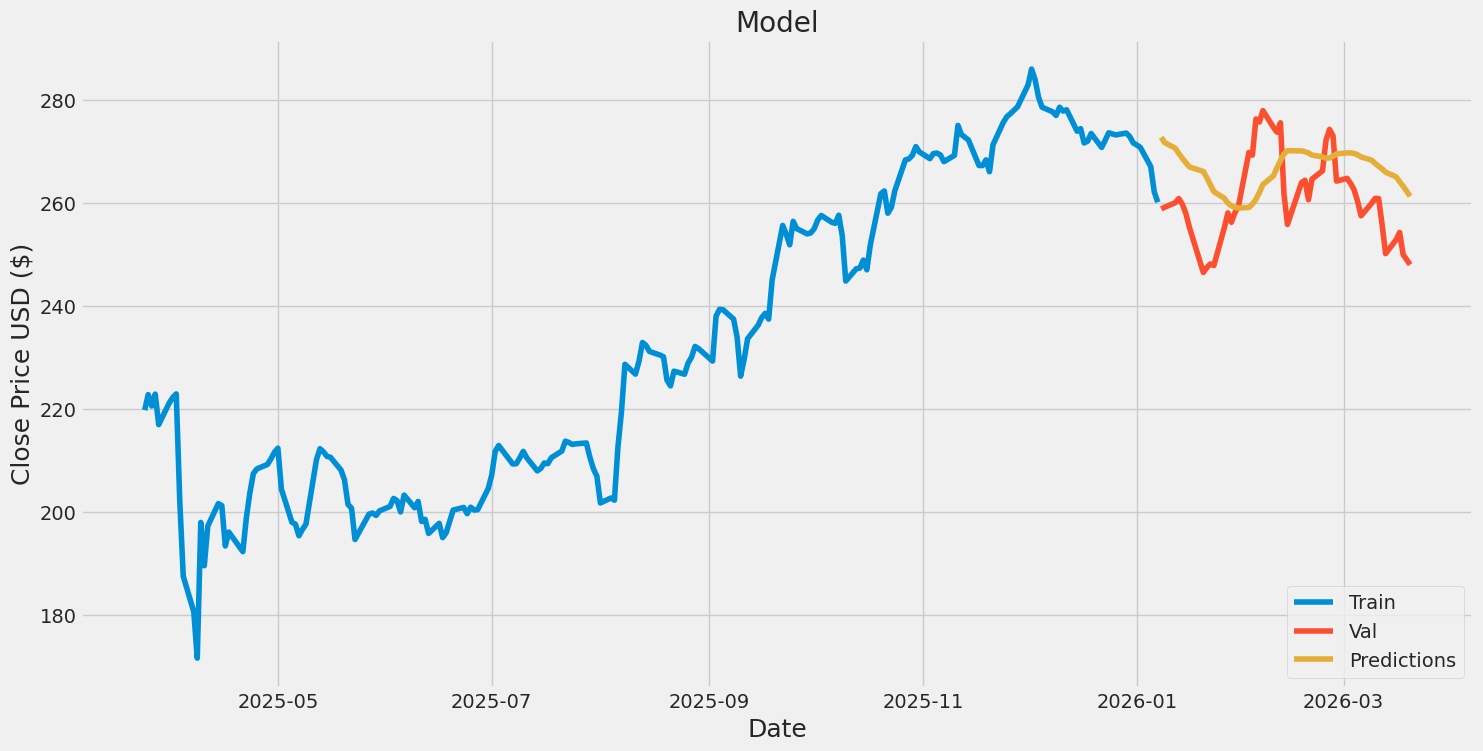

In [41]:
# Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [42]:
valid

Price,Close,Predictions
Ticker,AAPL,
Date,,
2026-01-08,258.797852,272.682495
2026-01-09,259.127533,271.648773
2026-01-12,260.006714,270.571472
2026-01-13,260.805939,269.544617
2026-01-14,259.716980,268.625458
2026-01-15,257.968597,267.775391
2026-01-16,255.291122,266.942932
2026-01-20,246.469376,266.057739


## Conclusion :

### Predicted results resemble actual values to a good extent. Hence the model is successfully executed with near accurate expectancy.